
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v2:</b>

    
<b>Overall Feedback</b>
    
Hello Dylan,

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v2:` section.


If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

# Instacart Market Basket Analysis

## Importing the required libraries

In [4]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')


order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Analyze your data

In the cells below, display the datasets using `.info()` and `.head()` to gain insights into their structure and content.

- `.info()`: Provides a concise summary of the dataset, including the data types, non-null counts, and memory usage.
- `.head()`: Displays the first few rows of the dataset, offering a quick overview of the data values.

In [6]:
# In this cell, type "orders" below this line and execute the cell

print(orders)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478962   3210681     5617             5          1                 14   
478963   3270802   112087             2          3                 13   
478964    885349    82944            16          2                 11   
478965    216274     4391             3          3                  8   
478966   2071924     1730            18          1                 14   

        days_since_prior_order  
0                         30.0  
1                          9.0  
2                       

In [7]:
# In this cell, type "products" below this line and execute the cell
print(products)

       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
0            61             19  
1           104             13  
2            94              7  
3  

Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for your analysis.

In [8]:
# In this cell, type "orders.info() below this line and execute the cell
orders.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

In [9]:
# In this cell, run order_products.info() below, but include the argument show_counts=True since this is a large file.
order_products.info(show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

## Find and Remove Missing Values

We noticed that some columns contain missing values.

Here are some useful code snippets:

```python
# Identify missing values in each column
print(dataset.isnull().sum())

# Display rows where a specific column has missing values
print(dataset[dataset['column_name'].isna()])

# Confirm no missing values remain
print(dataset.isnull().sum())
```

### `products` Data Frame

We will begin by addressing the missing values in the `products` data frame.

In [10]:
# Display rows where the product_name column has missing values
print(products.isnull().sum())
print(products[products['product_name'].isna()])

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64
       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [11]:
# Combine conditions to check for missing product names in aisles other than 100
print(products['product_name'].isna() & (products['aisle_id'] != 100))



0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Length: 49694, dtype: bool


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your boolean filter is meant to return only rows where `product_name` is missing and `aisle_id` is not 100, but the output shows the full dataset—so the mask isn’t being applied as intended. Consider rebuilding the condition step-by-step (first filter to missing `product_name`, then check whether any of those have `aisle_id != 100`) to ensure only the targeted subset is displayed.

</div>


In [12]:
# Combine conditions to check for missing product names in aisles other than 21
print(products['product_name'].isna() & (products['department_id'] != 21))

0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Length: 49694, dtype: bool


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The boolean logic here is off: `~products['department_id'] == 21` does not mean “department_id is not 21”. Consider rewriting the condition using an explicit not-equal comparison (and keeping the `product_name`-is-missing condition) so you’re truly checking for missing names outside department 21.

</div>


To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [13]:
# What is this aisle and department?
print(aisles[aisles['aisle_id'] == 100])
print(departments[departments['department_id'] == 21])
#Department 21 and aisle 100 don't exist. Which is why there are no product names associated with them.

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


In [14]:
# Fill missing product names with 'Unknown'
products['product_name'] = products['product_name'].fillna(value='Unknown', inplace=False)
print(products.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   49694 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You created a new column (`products_name`) instead of filling missing values in the existing `product_name` column, so the original `product_name` still contains NaNs. For this task, consider imputing directly into `product_name` and then confirming with another missing-value check so later grouping/merging on `product_name` won’t be affected.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well done!

### `orders` data frame. Now let's fill in missing values from the `orders` table.


In [15]:
# Display rows where the days_since_prior_order column has missing values
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [16]:
# Are there any missing values where it's not a customer's first order?
print(orders[orders['days_since_prior_order'].isna() & orders['order_number'] > 1])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame

Now let's fill in missing values from the order_products table.

In [17]:
# Display rows where the add_to_cart_order column has missing values
print(order_products[order_products['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [18]:
# Use .min() and .max() to find the minimum and maximum values for this column.

print('Minimum Value: ', order_products['add_to_cart_order'].min())
print('Maximum Value: ', order_products['add_to_cart_order'].max())


Minimum Value:  1.0
Maximum Value:  64.0


In [19]:

# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_add_to_cart_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id']
print(missing_add_to_cart_orders)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [20]:


# Do all orders with missing values have more than 64 products?

print(order_products.groupby('order_id').size()[missing_add_to_cart_orders])


order_id
2449164    76
1968313    80
2926893    92
1717990    86
1959075    98
           ..
1800005    92
1633337    67
404157     76
1673227    78
1832957    78
Length: 836, dtype: int64


In [21]:

# Replace missing values with 999
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)

# Convert to integer type
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

# Check the data type
print(order_products['add_to_cart_order'].dtype)

int64


For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All the Datasets

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our analysis. To handle this:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.
3. Optionally, you can set the `keep` parameter in `.drop_duplicates()` to specify which duplicate to retain (`'first'` or `'last'`).

Here is some example code for reference:
```python
# Check for duplicates
print(dataset.duplicated().sum())  # Number of duplicate rows

# View duplicate rows
print(dataset[dataset.duplicated()]

# Remove duplicates
dataset = dataset.drop_duplicates().reset_index(drop=True)

# Confirm removal
print(dataset.duplicated().sum())  # Should return 0
```

Repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [22]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


In [23]:
# View the duplicate rows
print(orders[orders.duplicated()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [24]:
# Remove duplicate orders
orders = orders.drop_duplicates().reset_index(drop=True)

In [25]:
# Double check for duplicate rows
print(orders.duplicated().sum())  # Should return 0

0


### `products` data frame

In [26]:
# Check for fully duplicate rows
print(products.duplicated().sum())

0


In [27]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products[products.duplicated(subset='product_id')])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [28]:

# Check for just duplicate product names (convert names to lowercase to compare better)
print(products['product_name'].str.lower().duplicated())


0        False
1        False
2        False
3        False
4        False
         ...  
49689     True
49690     True
49691     True
49692     True
49693     True
Name: product_name, Length: 49694, dtype: bool


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The goal here is to *identify/count duplicate product names case-insensitively*. Printing `products['product_name'].str.lower()` doesn’t test duplicates—consider using `.duplicated()` on the lowercased Series (and optionally displaying the duplicated rows) to demonstrate how many duplicates exist before you remove them.

</div>


Let's see what that looks like in our dataset :

In [29]:
print(products[products['product_name'].str.lower()== 'high performance energy drink'])

       product_id                   product_name  aisle_id  department_id
22540       22541  High Performance Energy Drink        64              7
49689       49690  HIGH PERFORMANCE ENERGY DRINK        64              7


In [30]:

# Drop duplicate product names (case insensitive)
# Create a temporary lowercase column for comparison
products_clean = products.copy()
products_clean['product_name_lower'] = products_clean['product_name'].str.lower()

# Drop duplicates based on the lowercase product name, keeping the first occurrence
products = products_clean.drop_duplicates(subset=['product_name_lower']).reset_index(drop=True)

# Remove the temporary column
products = products.drop('product_name_lower', axis=1)

# Check how many duplicates were removed
print(f"Remaining products: {len(products)}")
print(products.duplicated().sum())

Remaining products: 48333
0


### `departments` data frame

In [31]:

# Check for duplicate entries in the departments dataframe
print(departments.duplicated().sum())
print(departments[departments.duplicated()])


0
Empty DataFrame
Columns: [department_id, department]
Index: []


### `aisles` data frame

In [32]:
# Check for aisles entries in the departments dataframe
print(aisles.duplicated().sum())

0


### `order_products` data frame

In [33]:
# Check for duplicate entries in the order_products dataframe
print(order_products.duplicated().sum())

0


We have now successfully cleaned our data. Let's begin our exploratory data analysis.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

To verify that the values in the `order_hour_of_day` and `order_dow` columns are sensible:

1. **Check unique values**: Use `.unique()` on each column to extract all distinct values present.
2. **Sort the results**: Use `sorted()` to arrange the unique values in ascending order for easier verification.
3. **Validate ranges**:
   - Ensure `order_hour_of_day` values range from 0 to 23 (representing hours of the day).
   - Ensure `order_dow` values range from 0 to 6 (representing days of the week).

This process confirms that the data aligns with expected ranges and there are no out-of-bound or invalid entries.

In [34]:
# Check unique values
unique_order_hour_of_day = orders['order_hour_of_day'].unique()

# Sort in ascending order
sort_unique_order_hour_of_day = sorted(unique_order_hour_of_day)

# View list and validate range (0-23)
print(sort_unique_order_hour_of_day)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work validating the `order_hour_of_day` range by sorting the unique values—this clearly confirms the data spans 0–23.

</div>


In [35]:
# Check unique values
unique_order_dow = orders['order_dow'].unique()

# Sort in ascending order
sort_unique_order_dow= sorted(unique_order_dow)

# View list and validate range (0-6)
print(sort_unique_order_dow)


[0, 1, 2, 3, 4, 5, 6]


### [A2] What time of day do people shop for groceries?

To determine the time of day people shop for groceries, analyze the order_hour_of_day column in the orders dataset. Use .value_counts() to count the number of orders placed at each hour, and then sort the results by the hour for a clear chronological order.

Finally, visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


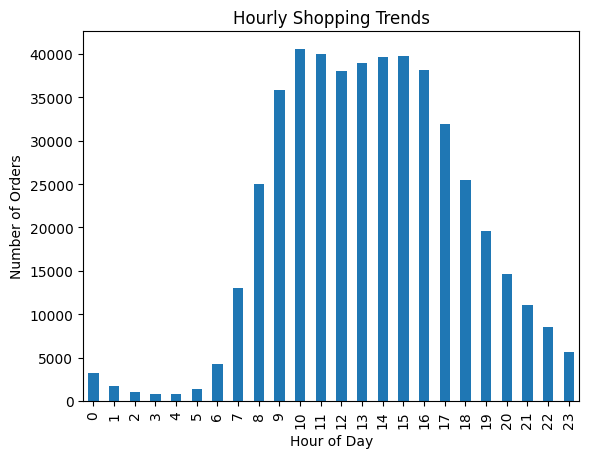

In [36]:


# Number of orders each hour
num_of_orders = orders['order_hour_of_day'].value_counts()

# Sort by hour
sort_num_of_orders = num_of_orders.sort_index()

# Create bar graph
sort_num_of_orders.plot(kind='bar',
                       title='Hourly Shopping Trends',
                       xlabel='Hour of Day',
                       ylabel='Number of Orders',
                        xlim=[0,23],
                       )
# View result
print(sort_num_of_orders)
plt.show()



Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good job computing the hourly order counts, plotting them clearly, and summarizing the main peak hours in a way that matches the visualization.

</div>


### [A3] What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

Visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


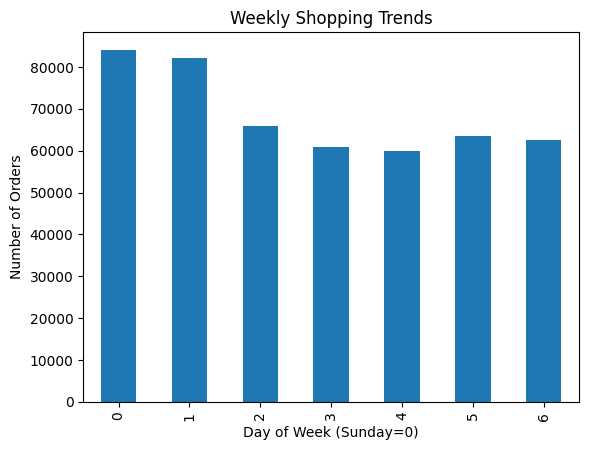

In [37]:
# Number of orders each hour
num_of_orders_dow = orders['order_dow'].value_counts()

# Sort by hour
sort_num_of_orders_dow= num_of_orders_dow.sort_index()

# Create bar graph
sort_num_of_orders_dow.plot(kind='bar',
                       title='Weekly Shopping Trends',
                       xlabel='Day of Week (Sunday=0)',
                       ylabel='Number of Orders',
                        xlim=[0,6],
                       )
# View result
print(sort_num_of_orders_dow)
plt.show()


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work: you computed the day-of-week counts, sorted by day index, and produced a clear bar chart with helpful labels and a title.

</div>


The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### [A4] How long do people wait until placing another order?

To understand how long people wait before placing another order, analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

Visualize the data using a bar plot to observe patterns in ordering frequency over time.

0.0      9589
1.0     20179
2.0     27138
3.0     30224
4.0     31006
5.0     30096
6.0     33930
7.0     44577
8.0     25361
9.0     16753
10.0    13309
11.0    11467
12.0    10658
13.0    11737
14.0    13992
15.0     9416
16.0     6587
17.0     5498
18.0     4971
19.0     4939
20.0     5302
21.0     6448
22.0     4514
23.0     3337
24.0     3015
25.0     2711
26.0     2640
27.0     2986
28.0     3745
29.0     2673
30.0    51337
Name: days_since_prior_order, dtype: int64


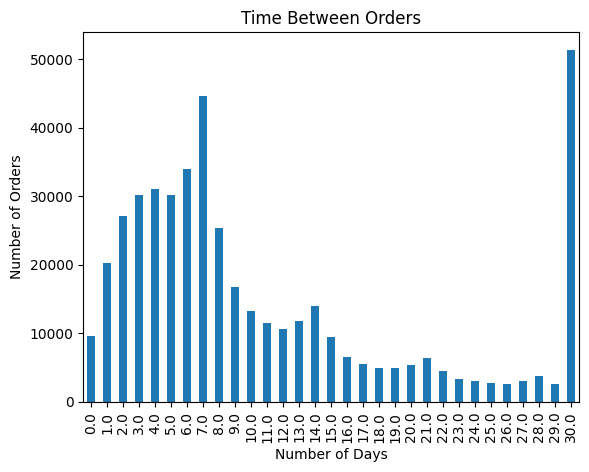

In [38]:
# Number of days since prior order
num_of_days_since_prior_order = orders['days_since_prior_order'].value_counts()

# Sort by Day of week
sort_num_of_days_since_prior_order= num_of_days_since_prior_order.sort_index()

# Create bar graph
sort_num_of_days_since_prior_order.plot(kind='bar',
                       title='Time Between Orders',
                       xlabel='Number of Days',
                       ylabel='Number of Orders',
                       )
#view result
print(sort_num_of_days_since_prior_order)
plt.show()

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong interpretation of the distribution (including plausible explanations for the spike at 0 and the spike at 30), and the plot labeling makes the chart easy to read.

</div>


Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the bar charts for both days and describe the differences that you see.

To determine if there's a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, follow these steps:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, plot bar charts for both days to visually compare the distribution of order times. Look for patterns such as peaks or differences in the busiest times throughout the day.

In [39]:
# Filter for only Wednesday and Saturday
wed_orders = orders['order_dow'] == 3
sat_orders = orders['order_dow'] == 6
print(orders[wed_orders][['order_dow', 'order_hour_of_day']])
print(orders[sat_orders][['order_dow', 'order_hour_of_day']])


        order_dow  order_hour_of_day
6               3                  8
16              3                 15
28              3                 10
30              3                 15
35              3                 19
...           ...                ...
478902          3                  7
478931          3                  8
478941          3                 10
478948          3                 13
478950          3                  8

[60897 rows x 2 columns]
        order_dow  order_hour_of_day
0               6                 13
11              6                 16
14              6                 11
20              6                  9
26              6                 18
...           ...                ...
478909          6                 10
478915          6                 19
478928          6                 10
478939          6                 21
478946          6                 10

[62649 rows x 2 columns]


In [40]:
# Count how many orders per hour
get_wed_hrs_orders = orders[wed_orders]['order_hour_of_day'].value_counts().sort_index()
get_sat_hrs_orders = orders[sat_orders]['order_hour_of_day'].value_counts().sort_index()

print(get_wed_hrs_orders)
print(get_sat_hrs_orders)

0      373
1      215
2      106
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_hour_of_day, dtype: int64
0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64


In [41]:
# Merge Wednesday and saturday lists
Wed_Sat_orders_per_hour = pd.concat([get_wed_hrs_orders, get_sat_hrs_orders], 
                                   axis=1, 
                                   keys=['Wednesday', 'Saturday'])
print(Wed_Sat_orders_per_hour)

    Wednesday  Saturday
0         373       464
1         215       254
2         106       177
3         101       125
4         108       118
5         170       161
6         643       451
7        1732      1619
8        3125      3246
9        4490      4311
10       5026      4919
11       5004      5116
12       4688      5132
13       4674      5323
14       4774      5375
15       5163      5188
16       4976      5029
17       4175      4295
18       3463      3338
19       2652      2610
20       1917      1847
21       1450      1473
22       1154      1185
23        718       893


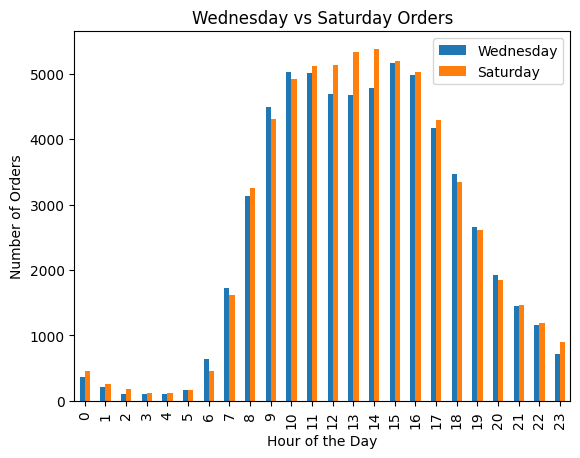

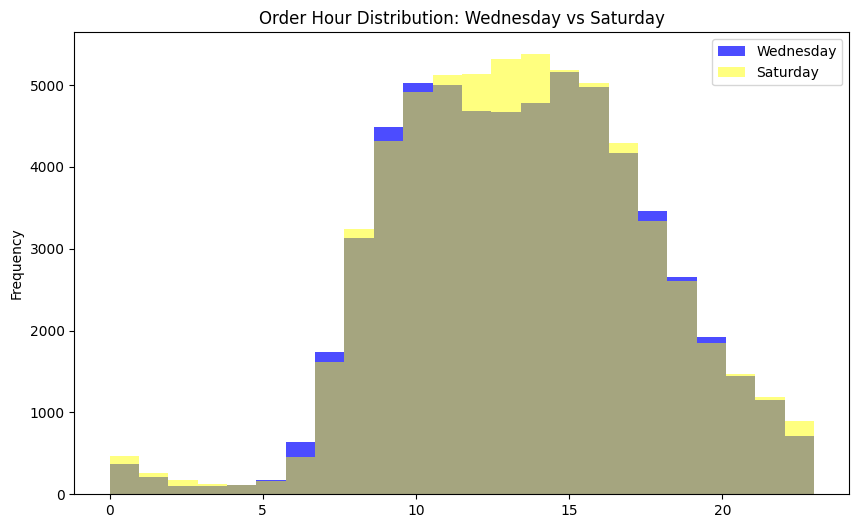

In [42]:
# Create a bar graph to compare Wednesday and Saturday
Wed_Sat_orders_per_hour.plot(kind='bar',
                       title='Wednesday vs Saturday Orders',
                       xlabel='Hour of the Day',
                       ylabel='Number of Orders'
                       )
plt.show()

# Extract the raw order hour data for each day (like before)
wed_hours = orders[wed_orders]['order_hour_of_day']
sat_hours = orders[sat_orders]['order_hour_of_day']

# Plot Wednesday histogram
wed_hours.plot(kind='hist', bins=24, alpha=0.7, label='Wednesday', color='blue',
              title='Order Hour Distribution: Wednesday vs Saturday',
              xlabel='Hour of Day',
              ylabel='Number of Orders',
              figsize=(10, 6)
              )

# Plot Saturday histogram on the same axes
sat_hours.plot(kind='hist', bins=24, alpha=0.5, label='Saturday', color='yellow')
plt.legend()
plt.show()



<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The prompt asks for histograms of `order_hour_of_day` for Wednesdays vs Saturdays. You currently plot a bar chart of hourly counts; while informative, it doesn’t match the requested plot type. Consider plotting both distributions as histograms on the same axes (with transparency) so the shapes can be compared directly.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Well done!

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### [B2] What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

Adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [43]:
# Group data by user_id and count_ order_id to find how many orders per person
orders_per_customer = orders.groupby('user_id')['order_id'].count()
print(orders_per_customer)

# Sort results
sort_orders_per_customer = orders_per_customer.sort_values()
print(sort_orders_per_customer)

user_id
2         2
4         2
5         1
6         2
7         2
         ..
206203    1
206206    7
206207    5
206208    9
206209    2
Name: order_id, Length: 157437, dtype: int64
user_id
152331     1
139876     1
60408      1
139873     1
139871     1
          ..
66664     24
148162    24
78375     25
193164    26
149605    28
Name: order_id, Length: 157437, dtype: int64


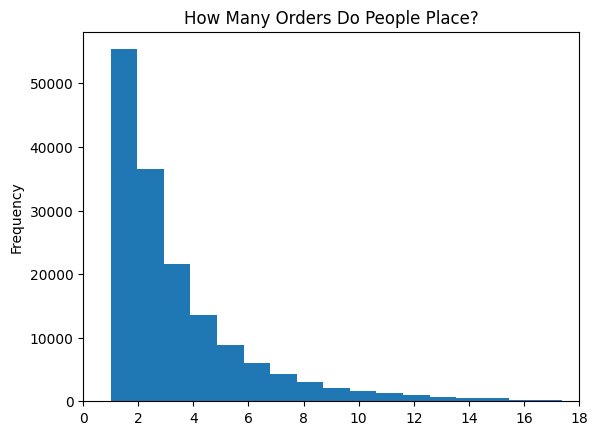

In [44]:
# Create a Histogram to view the trend
sort_orders_per_customer.plot(kind='hist',
                             title='How Many Orders Do People Place?',
                             bins=28,
                             xlim=[0,18]
                             )
plt.show()

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section is complete: you calculated orders per customer correctly with `groupby` + `count`, visualized the distribution with a labeled histogram, and summarized the main trend clearly.

</div>


### [B3] What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give you a clear view of the most popular products and their ranking.


In [45]:
# Merge order_products and products on product_id
merge_product_id = products.merge(order_products, on='product_id')
print(merge_product_id)

         product_id                product_name  aisle_id  department_id  \
0                 1  Chocolate Sandwich Cookies        61             19   
1                 1  Chocolate Sandwich Cookies        61             19   
2                 1  Chocolate Sandwich Cookies        61             19   
3                 1  Chocolate Sandwich Cookies        61             19   
4                 1  Chocolate Sandwich Cookies        61             19   
...             ...                         ...       ...            ...   
4524190       49688      Fresh Foaming Cleanser        73             11   
4524191       49688      Fresh Foaming Cleanser        73             11   
4524192       49688      Fresh Foaming Cleanser        73             11   
4524193       49688      Fresh Foaming Cleanser        73             11   
4524194       49688      Fresh Foaming Cleanser        73             11   

         order_id  add_to_cart_order  reordered  
0         1104373                 11 

In [46]:
# Group by product_id and product_name, then count occurrences
product_counts = merge_product_id.groupby(['product_id', 'product_name']).size()

# Sort to get the most popular products
top_20_products = product_counts.sort_values(ascending=False).head(20)
print("Top 20 Most Popular Products:")
print(top_20_products)

Top 20 Most Popular Products:
product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
dtype: int64


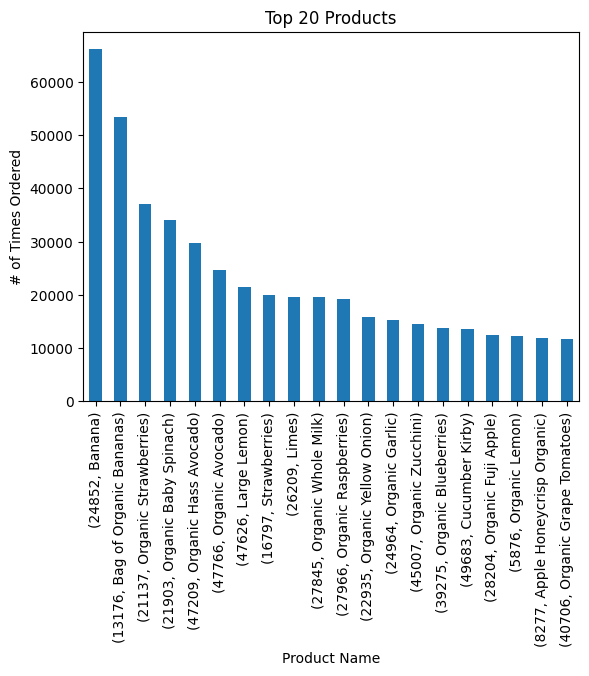

In [47]:
# Vizualize Results in a Bar Chart
top_20_products.plot(kind='bar',
                    xlabel='Product Name',
                    ylabel='# of Times Ordered',
                    title='Top 20 Products')
plt.show()

The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work: you merged the tables correctly, computed product order frequencies, displayed the top 20 with both IDs and names, and added a clear plot.

</div>


# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help you understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [48]:
# Group Data by 'order_id'
order_counts = order_products.groupby('order_id')['product_id'].count()
print(order_counts)

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


In [49]:
# Aggregate using .value_counts and then sort
order_counts_dist = order_counts.value_counts().sort_index()
print(order_counts_dist)

1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: product_id, Length: 90, dtype: int64


Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

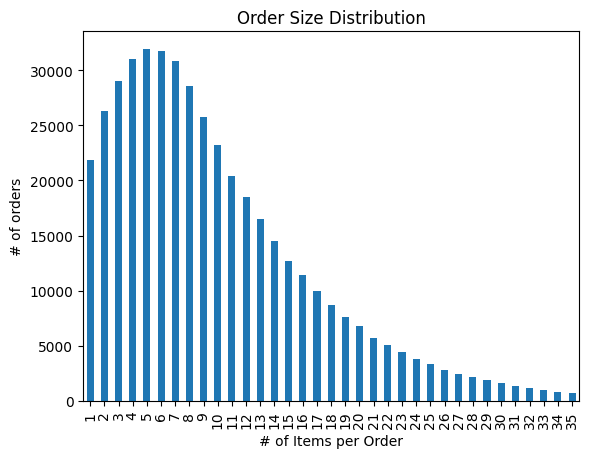

In [50]:
# Plot a bar graph to visualize the trends
order_counts_dist.head(35).plot(kind='bar',
                       xlabel='# of Items per Order',
                       ylabel='# of orders',
                       title='Order Size Distribution')
plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Well done: grouping by `order_id` to compute items-per-order is correct, and trimming the plot to the first 35 item counts makes the distribution much easier to interpret.

</div>


The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

To find the top 20 most frequently reordered items:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.
This process highlights the products that customers consistently return to and reorder.

In [51]:
# Filter for reordered products
reordered_products = order_products[order_products['reordered'] == 1]

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Follow-up note: this task requires a visualization of the top 20 reordered items in addition to listing names and product IDs. (You address the plot later—consider keeping the workflow tightly connected by adding the plot immediately after computing the top 20.)

</div>


In [52]:
# Merge with products to get product names
reordered_items = reordered_products.merge(products, on='product_id')

In [53]:
# Group by product_id and product_name
reorder_counts = reordered_items.groupby(['product_id', 'product_name']).size()

# Sort and get top 20
top_20_reordered = reorder_counts.sort_values(ascending=False).head(20)
print(top_20_reordered)

product_id  product_name            
24852       Banana                      55763
13176       Bag of Organic Bananas      44450
21137       Organic Strawberries        28639
21903       Organic Baby Spinach        26233
47209       Organic Hass Avocado        23629
47766       Organic Avocado             18743
27845       Organic Whole Milk          16251
47626       Large Lemon                 15044
27966       Organic Raspberries         14748
16797       Strawberries                13945
26209       Limes                       13327
22935       Organic Yellow Onion        11145
24964       Organic Garlic              10411
45007       Organic Zucchini            10076
49683       Cucumber Kirby               9538
28204       Organic Fuji Apple           8989
8277        Apple Honeycrisp Organic     8836
39275       Organic Blueberries          8799
5876        Organic Lemon                8412
49235       Organic Half & Half          8389
dtype: int64


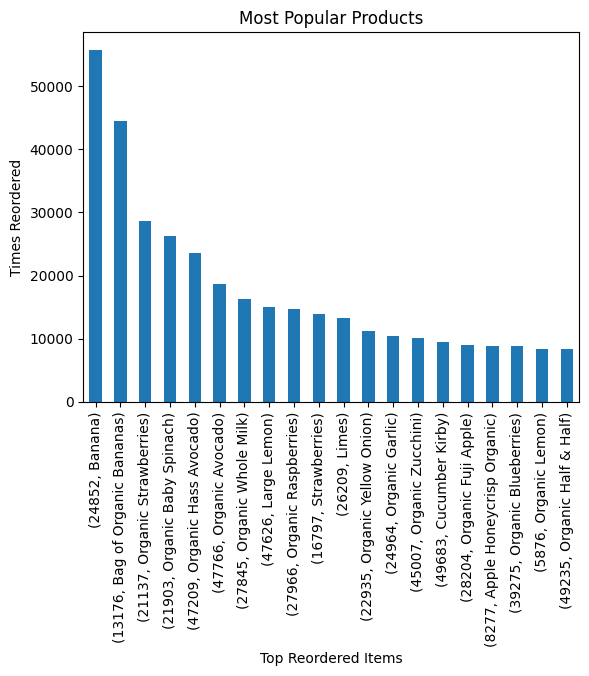

In [54]:
top_20_reordered.plot(kind='bar',
                     title='Most Popular Products',
                     xlabel='Top Reordered Items',
                     ylabel='Times Reordered'
                     )
plt.show()

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### [C3] For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.
This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


In [60]:
# Merge order_products with products to get product names
merged_data = order_products.merge(products, on='product_id')

(4524195, 7)


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For this task, consider presenting the final result explicitly as a 3-column table (product ID, product name, and a clearly named reorder-rate/proportion column). Printing intermediate shapes/heads is fine for sanity checks, but make sure the deliverable is a clean DataFrame that directly answers the question.

</div>


In [56]:

# Merge on product_id and product_name
total_products = merged_data.groupby(['product_id','product_name'])
# Calculate mean of reordered and sort in descending order
Reordered_mean = total_products['reordered'].mean().sort_values(ascending=False)
print(Reordered_mean)


product_id  product_name                              
18121       Jalapenos With Sea Salt                       1.0
27387       Banana Greek Nonfat Yogurt                    1.0
17773       Quinoa- with Olive Oil                        1.0
49063       Rosemary & Sea Salt Crackers                  1.0
14935       Kombucha Blueberry Basil                      1.0
                                                         ... 
25053       Frost Arctic Blitz Sports Drink               0.0
25051       Herb for Beef Gravy Mix                       0.0
25045       Bandages- Waterproof                          0.0
25044       Pure Pacific Mountain Strawberry Preserves    0.0
24793       Sea Salt- Course                              0.0
Name: reordered, Length: 44516, dtype: float64


In [57]:

# Convert to a dataframe
Reordered_mean_df = Reordered_mean.reset_index()
print(Reordered_mean_df)
# Sort by product_id
df_sorted_by_id = Reordered_mean_df.sort_values('product_id', ascending=True)
print(df_sorted_by_id)

       product_id                                product_name  reordered
0           18121                     Jalapenos With Sea Salt        1.0
1           27387                  Banana Greek Nonfat Yogurt        1.0
2           17773                      Quinoa- with Olive Oil        1.0
3           49063                Rosemary & Sea Salt Crackers        1.0
4           14935                    Kombucha Blueberry Basil        1.0
...           ...                                         ...        ...
44511       25053             Frost Arctic Blitz Sports Drink        0.0
44512       25051                     Herb for Beef Gravy Mix        0.0
44513       25045                        Bandages- Waterproof        0.0
44514       25044  Pure Pacific Mountain Strawberry Preserves        0.0
44515       24793                            Sea Salt- Course        0.0

[44516 rows x 3 columns]
       product_id                                       product_name  \
11957           1         

### [C4] For each customer, what proportion of their products ordered are reorders?

To calculate the proportion of products reordered by each customer:

1. **Merge the datasets**: Combine `order_products` with `orders` to link order and customer information.
2. **Group the data**: Group by `user_id` to focus on each customer's ordering behavior.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to determine the proportion of products reordered by each customer.
4. **Sort the results**: Use `.sort_values(ascending=False)` to identify customers with the highest reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to format the grouped data into a structured DataFrame for further analysis.
This analysis reveals the extent to which individual customers reorder products, providing insights into customer loyalty and preferences.


In [61]:
# Merge order_products and orders on order_id
merged_orders = order_products.merge(orders, on='order_id')
# Group by user_id and sort in descending order
total_users_reordered = merged_orders.groupby('user_id')['reordered'].mean().sort_values(ascending=False)

print(total_users_reordered)

user_id
137587    1.0
173474    1.0
13918     1.0
62300     1.0
62307     1.0
         ... 
190953    0.0
119371    0.0
63173     0.0
63163     0.0
165726    0.0
Name: reordered, Length: 149626, dtype: float64


In [63]:
# Convert to data frame
total_users_df = total_users_reordered.reset_index()
print(total_users_df)

        user_id  reordered
0        137587        1.0
1        173474        1.0
2         13918        1.0
3         62300        1.0
4         62307        1.0
...         ...        ...
149621   190953        0.0
149622   119371        0.0
149623    63173        0.0
149624    63163        0.0
149625   165726        0.0

[149626 rows x 2 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This will error because `total_users` is not defined; the Series you created above is named `total_users_reordered`. Consider resetting the index on the correct object so you can produce the per-customer reorder-proportion DataFrame successfully.

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Awesome job

### [C5] What are the top 20 items that people put in their carts first?

To identify the top 20 items that people most frequently add to their carts first:

1. **Merge the datasets**: Combine `order_products` with `products` to link product names and IDs.
2. **Filter the data**: Focus on rows where `add_to_cart_order` equals 1, indicating the first item added to the cart.
3. **Group the data**: Group by `product_id` and `product_name` to aggregate the count of how often each product was the first in a cart.
4. **Count occurrences**: Use `.count()` to calculate the total number of times each product was the first added.
5. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their first-in-cart frequency.
6. **Display the top 20**: Use `.head(20)` to extract the most popular first-in-cart items.
This provides insights into which products customers prioritize in their shopping process.

In [64]:
# Merge order_products and products
merge_products = order_products.merge(products, on='product_id')
# Filter Data where add_to_cart_order == 1
first_cart_products = merge_products[merge_products['add_to_cart_order'] == 1]
print(first_cart_products)

         order_id  product_id  add_to_cart_order  reordered  \
6         1463503       11440                  1          0   
17        2201430       11440                  1          1   
21        1036054       11440                  1          1   
50        3008652       11440                  1          1   
62        2946144       11440                  1          1   
...           ...         ...                ...        ...   
4524162   1518168       16952                  1          0   
4524166   1776450       21507                  1          0   
4524183   2333206       25467                  1          0   
4524193    532895        8182                  1          0   
4524194   3132243       40024                  1          0   

                                     product_name  aisle_id  department_id  
6                  Chicken Breast Tenders Breaded       129              1  
17                 Chicken Breast Tenders Breaded       129              1  
21          

In [65]:
# Group data by product_id and product_name and count
first_cart_products_name = first_cart_products.groupby(['product_id', 'product_name']).size()

In [66]:
# Sort in descending order
sort_first_cart_products_name = first_cart_products_name.sort_values(ascending=False)
print(sort_first_cart_products_name)

product_id  product_name                                
24852       Banana                                          15562
13176       Bag of Organic Bananas                          11026
27845       Organic Whole Milk                               4363
21137       Organic Strawberries                             3946
47209       Organic Hass Avocado                             3390
                                                            ...  
24825       Savory Shreds with Chicken in Gravy Cat Food        1
24827       Pepperoni Provolone Cheese & Breadsticks            1
24837       Organic Dried Mushrooms Medley                      1
24839       Dark Chocolate Coconut Bars                         1
49688       Fresh Foaming Cleanser                              1
Length: 26443, dtype: int64


The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.

In [67]:
# Print Top 20 List
print(sort_first_cart_products_name.head(20))

product_id  product_name               
24852       Banana                         15562
13176       Bag of Organic Bananas         11026
27845       Organic Whole Milk              4363
21137       Organic Strawberries            3946
47209       Organic Hass Avocado            3390
21903       Organic Baby Spinach            3336
47766       Organic Avocado                 3044
19660       Spring Water                    2336
16797       Strawberries                    2308
27966       Organic Raspberries             2024
44632       Sparkling Water Grapefruit      1914
49235       Organic Half & Half             1797
47626       Large Lemon                     1737
196         Soda                            1733
38689       Organic Reduced Fat Milk        1397
26209       Limes                           1370
12341       Hass Avocados                   1340
5785        Organic Reduced Fat 2% Milk     1310
27086       Half & Half                     1309
43352       Raspberries      